In [34]:
!pip install pennylane --quiet

In [35]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
import math

In [36]:
n_qubits = 6        # number of qubits
n_layers = 6         # number of repetition layers
n_steps = 200         # optimization steps
learning_rate = 0.1   # for gradient descent
step_size = 0.01 # for QNG

In [37]:
dev = qml.device('lightning.qubit', wires=n_qubits)
# Build the Hamiltonian: H = - sum Z_i Z_{i+1} - sum X_i
def build_hamiltonian(n):
    """Return the Hamiltonian
    H = - sum Z_i Z_{i+1} - sum X_i
     """
    coeffs = []
    ops = []
    # - sum Z_i Z_{i+1}
    for i in range(n - 1):
        coeffs.append(-1.0)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(i + 1))
    # - sum X_i
    for i in range(n):
        coeffs.append(-1.0)
        ops.append(qml.PauliX(i))
    return qml.Hamiltonian(coeffs, ops)

H = build_hamiltonian(n_qubits)

In [38]:
def circuit(params):
    """Circuit with n_layers of (RX, RY) + CNOT entanglement."""
    params = params.reshape((n_layers, n_qubits, 2))
    for layer in range(n_layers):
        # Rotation layer
        for qubit in range(n_qubits):
            qml.RX(params[layer, qubit, 0], wires=qubit)
            qml.RY(params[layer, qubit, 1], wires=qubit)
        # Entanglement layer (linear CNOT chain)
        for qubit in range(n_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])
        qml.Barrier()


In [39]:
@qml.qnode(dev)
def cost_fn(params):
    circuit(params)
    return qml.expval(H)

In [40]:
@qml.qnode(dev)
def variance_fn(params):
    circuit(params) # Your ansatz (without the @qml.qnode decorator)
    return qml.var(H)

Step   0  Energy = 0.459314
Step  10  Energy = -1.074904
Step  20  Energy = -2.092656
Step  30  Energy = -2.976616
Step  40  Energy = -3.798282
Step  50  Energy = -4.603281
Step  60  Energy = -5.489843
Step  70  Energy = -6.194829
Step  80  Energy = -6.615767
Step  90  Energy = -6.863288
Step 100  Energy = -7.008204
Step 110  Energy = -7.093820
Step 120  Energy = -7.146383
Step 130  Energy = -7.180288
Step 140  Energy = -7.203182
Step 150  Energy = -7.219250
Step 160  Energy = -7.230890
Step 170  Energy = -7.239544
Step 180  Energy = -7.246110
Step 190  Energy = -7.251175

Final energy = -7.254781


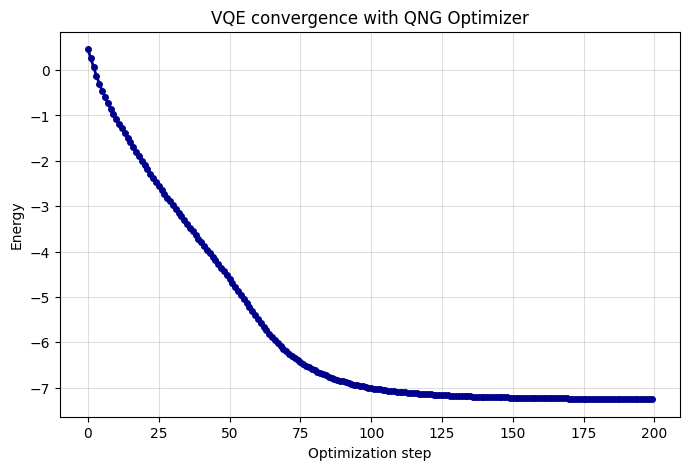

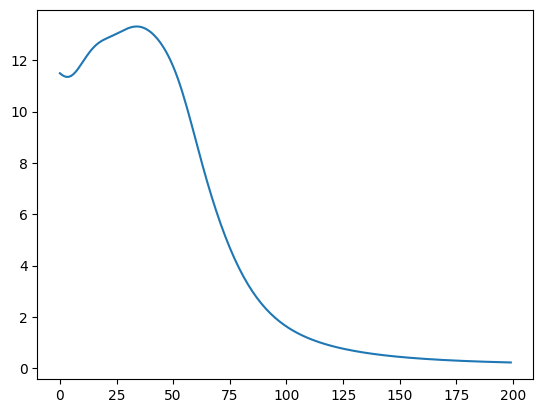

In [41]:
np.random.seed(42)
params = np.random.randn(n_layers * n_qubits * 2, requires_grad=True)

opt = qml.QNGOptimizer(stepsize=step_size)
energies_adam = []
aaa = []
for step in range(n_steps):
    params, energy = opt.step_and_cost(cost_fn, params)
    energies_adam.append(energy)
    aaa.append(variance_fn(params))
    if step % 10 == 0:
        print(f"Step {step:3d}  Energy = {energy:.6f}")

print(f"\nFinal energy = {energies_adam[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(energies_adam, 'o-', color='darkblue', lw=2, markersize=4)
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.title("VQE convergence with QNG Optimizer")
plt.grid(alpha=0.4)
plt.show()

plt.plot(aaa)

[-7.29622981 -6.81408309 -5.87781026 -5.39566354 -5.02397082 -4.5418241
 -4.30218682 -3.8200401  -3.75440571 -3.60555128 -3.41246254 -3.27225899
 -3.12340455 -2.93031582 -2.88376727 -2.40162055 -2.33598616 -2.02992783
 -1.99404299 -1.85383944 -1.54778111 -1.51189627 -1.48214672 -1.14020355
 -1.         -0.76036272 -0.65805683 -0.61150828 -0.41841955 -0.27821599
 -0.12936156 -0.06372717  0.06372717  0.12936156  0.27821599  0.41841955
  0.61150828  0.65805683  0.76036272  1.          1.14020355  1.48214672
  1.51189627  1.54778111  1.85383944  1.99404299  2.02992783  2.33598616
  2.40162055  2.88376727  2.93031582  3.12340455  3.27225899  3.41246254
  3.60555128  3.75440571  3.8200401   4.30218682  4.5418241   5.02397082
  5.39566354  5.87781026  6.81408309  7.29622981]
Step   0  Energy = -0.651763
Step  10  Energy = -5.571044
Step  20  Energy = -5.152611
Step  30  Energy = -5.498432
Step  40  Energy = -5.244688
Step  50  Energy = -6.022219
Step  60  Energy = -5.918175
Step  70  Energy =

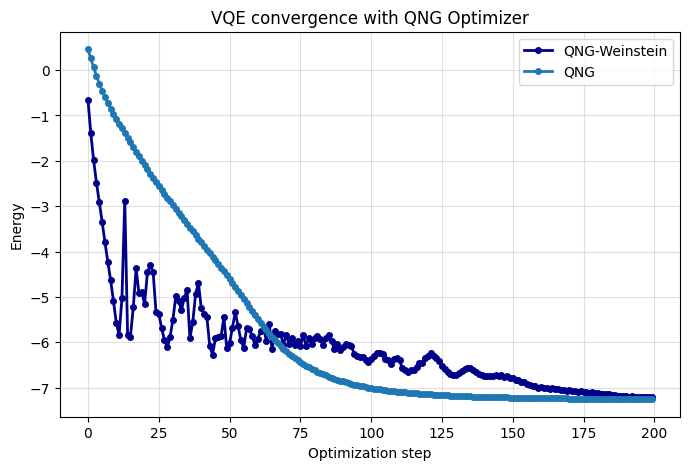

In [42]:
np.random.seed(42)
init_params = np.random.randn(n_layers * n_qubits * 2, requires_grad=True)
params = np.array(init_params, requires_grad=True)

H_matrix = qml.matrix(H)
min_step_size = float('inf')
eigenvalues = np.linalg.eigvalsh(H_matrix)
print(eigenvalues)
metric_fn = qml.metric_tensor(cost_fn, approx='block-diag')
grad_fn = qml.grad(cost_fn)

energies_weinstein = []
vs = []

for step in range(n_steps):
    F = metric_fn(params) + 1e-6 * np.eye(len(params))
    F_inv = np.linalg.inv(F)

    variance = variance_fn(params)
    vs.append(variance)
    # Weinstein bound step size
    step_size = 0.25 / (math.sqrt(variance) + 1e-6)
    min_step_size = min(min_step_size, step_size)

    params -= min_step_size * F_inv @ grad_fn(params)

    energy = cost_fn(params)
    energies_weinstein.append(energy)

    if step % 10 == 0:
        print(f"Step {step:3d}  Energy = {energy:.6f}")

print(f"\nFinal energy = {energies_weinstein[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(energies_weinstein, 'o-', color='darkblue', lw=2, markersize=4, label="QNG-Weinstein")
plt.plot(energies_adam, 'o-', lw=2, markersize=4, label="QNG")
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.legend()
plt.title("VQE convergence with QNG Optimizer")
plt.grid(alpha=0.4)
plt.show()

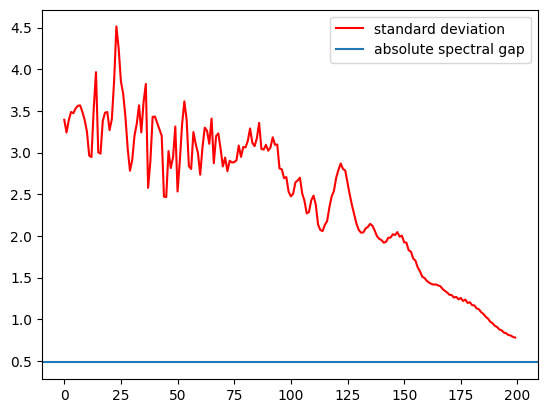

In [43]:
absolute_spectral_gap = eigenvalues[1] - eigenvalues[0]
plt.plot(np.sqrt(vs), color='red', label="standard deviation")
plt.axhline(absolute_spectral_gap, label="absolute spectral gap")
plt.legend()

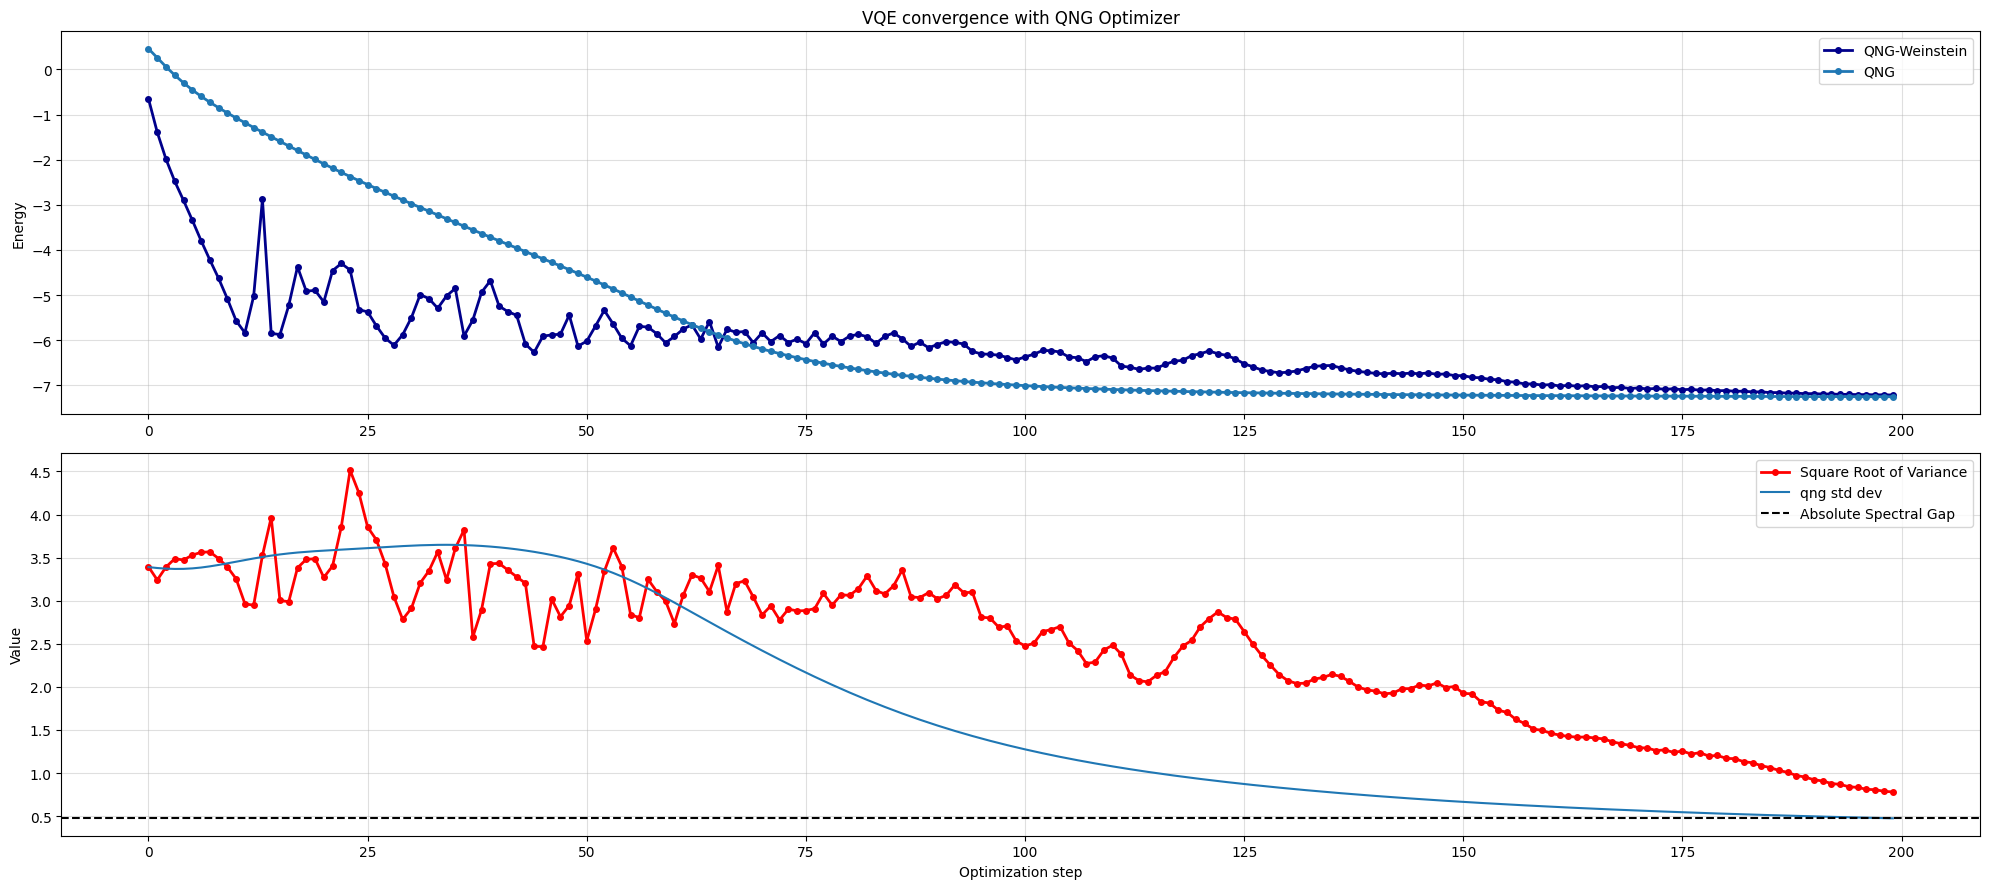

In [44]:
# Calculate the absolute spectral gap
absolute_spectral_gap = eigenvalues[1] - eigenvalues[0]

# Create the figure and subplots (2 rows, 1 column)
# Increased the overall figsize height to accommodate both plots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 9))

# --- Top Plot (axs[0]): Energy Convergence ---
axs[0].plot(energies_weinstein, 'o-', color='darkblue', lw=2, markersize=4, label="QNG-Weinstein")
axs[0].plot(energies_adam, 'o-', lw=2, markersize=4, label="QNG")
axs[0].set_ylabel("Energy")
axs[0].set_title("VQE convergence with QNG Optimizer")
axs[0].grid(alpha=0.4)
axs[0].legend()

# --- Bottom Plot (axs[1]): Variance and Spectral Gap ---
axs[1].plot(np.sqrt(vs), 'o-', color='red', lw=2, markersize=4, label="Square Root of Variance")
axs[1].plot(np.sqrt(aaa), label="qng std dev")
axs[1].axhline(absolute_spectral_gap, color='black', linestyle='--', label="Absolute Spectral Gap")
axs[1].set_xlabel("Optimization step")
axs[1].set_ylabel("Value")
axs[1].grid(alpha=0.4)
axs[1].legend()

# Automatically adjust spacing to prevent text clipping/overlap
plt.tight_layout()

# Render the stacked plots
plt.show()

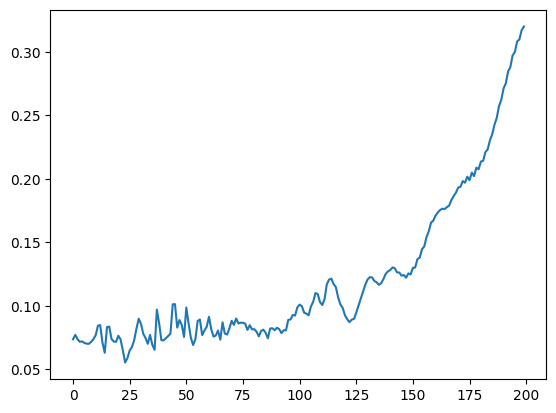

In [45]:
plt.plot(0.25/np.sqrt(vs))

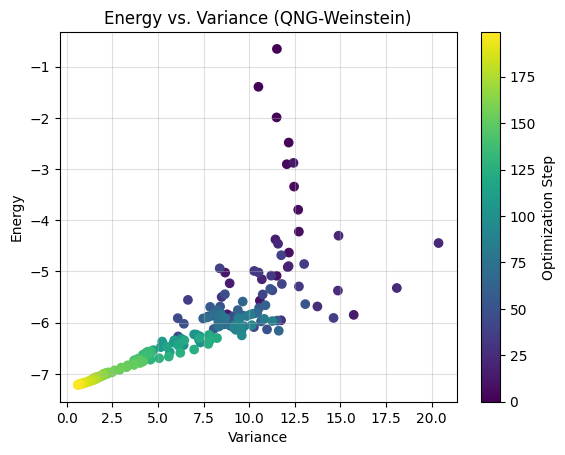

In [48]:
plt.scatter(x=vs, y=energies_weinstein, c=np.arange(len(vs)), cmap='viridis')
plt.xlabel("Variance")
plt.ylabel("Energy")
plt.title("Energy vs. Variance (QNG-Weinstein)")
plt.colorbar(label="Optimization Step") # Add a color bar to show the step progression
plt.grid(alpha=0.4)
plt.show()

Linear Regression Results:
  Slope: 0.1376
  Intercept: -7.2833
  R-value (correlation coefficient): 0.9672
  R-squared (goodness of fit): 0.9355
  P-value: 0.0000
  Standard Error: 0.0031


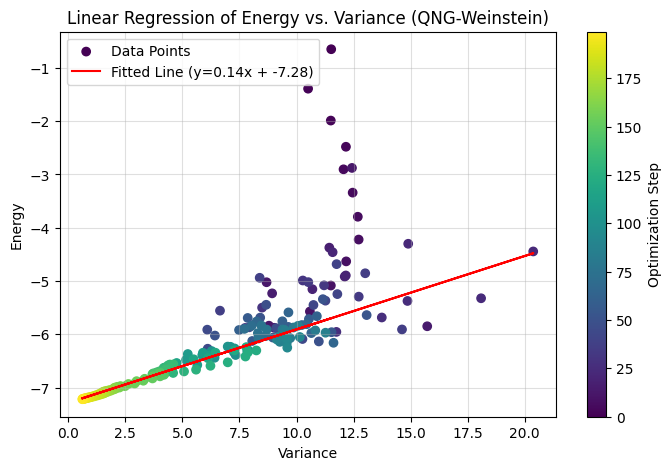

In [50]:
from scipy import stats

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(vs[60:], energies_weinstein[60:])

# Calculate R-squared for goodness of fit
r_squared = r_value**2

print(f"Linear Regression Results:")
print(f"  Slope: {slope:.4f}")
print(f"  Intercept: {intercept:.4f}")
print(f"  R-value (correlation coefficient): {r_value:.4f}")
print(f"  R-squared (goodness of fit): {r_squared:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Standard Error: {std_err:.4f}")

# Plot the data and the fitted line
plt.figure(figsize=(8, 5))
plt.scatter(x=vs, y=energies_weinstein, c=np.arange(len(vs)), cmap='viridis', label='Data Points')
plt.plot(vs, intercept + slope * np.array(vs), color='red', label=f'Fitted Line (y={slope:.2f}x + {intercept:.2f})')
plt.xlabel("Variance")
plt.ylabel("Energy")
plt.title("Linear Regression of Energy vs. Variance (QNG-Weinstein)")
plt.colorbar(label="Optimization Step")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

## Our optimizer

In [99]:
from scipy import stats

np.random.seed(42)
init_params = np.random.randn(n_layers * n_qubits * 2, requires_grad=True)
params = np.array(init_params, requires_grad=True)

H_matrix = qml.matrix(H)
min_step_size = float('inf')
eigenvalues = np.linalg.eigvalsh(H_matrix)
# print(eigenvalues)
metric_fn = qml.metric_tensor(cost_fn, approx='block-diag')
grad_fn = qml.grad(cost_fn)

energies_ours = []
vs_ours = []

is_temple = False
temple_step = 0

running_energy_estimate = []
running_spec_gap_estimate = []

temple_step_when = -1
w_size = 20

for step in range(n_steps):
    F = metric_fn(params) + 1e-6 * np.eye(len(params))
    F_inv = np.linalg.inv(F)

    variance = variance_fn(params)
    vs_ours.append(variance)

    if step > w_size+1:
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(vs_ours[-w_size:], energies_ours[-w_size:])
        running_energy_estimate.append(intercept)
        running_spec_gap_estimate.append(1/slope)
        # Calculate R-squared for goodness of fit
        r_squared = r_value**2

        if r_squared >= 0.7 and not is_temple:
            is_temple = True
            temple_step_when = step
            temple_step = 0.25 * slope

    else:
        running_energy_estimate.append(0)
        running_spec_gap_estimate.append(4)

    # Weinstein bound step size
    step_size = 0.25 / (math.sqrt(variance) + 1e-6)
    min_step_size = min(min_step_size, step_size)

    if is_temple:
        min_step_size = temple_step

    params -= min_step_size * F_inv @ grad_fn(params)

    energy = cost_fn(params)
    energies_ours.append(energy)

    if step % 10 == 0:
        print(f"Step {step:3d}  Energy = {energy:.6f}")

print(f"\nFinal energy = {energies_ours[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(energies_ours, 'o-', color='darkblue', lw=2, markersize=4, label=f"QNG-Ours, w_size={w_size}")
plt.plot(energies_adam, 'o-', lw=2, markersize=4, label="QNG")
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.legend()
plt.title("VQE convergence with QNG Optimizer")
plt.grid(alpha=0.4)
plt.show()

Step   0  Energy = -0.651763
Step  10  Energy = -5.571924
Step  20  Energy = -4.348216
Step  30  Energy = -6.270197
Step  40  Energy = -6.059623
Step  50  Energy = -5.830615
Step  60  Energy = -6.950618
Step  70  Energy = -6.785524
Step  80  Energy = -7.141072
Step  90  Energy = -7.123313
Step 100  Energy = -7.197366
Step 110  Energy = -7.231224


KeyboardInterrupt: 

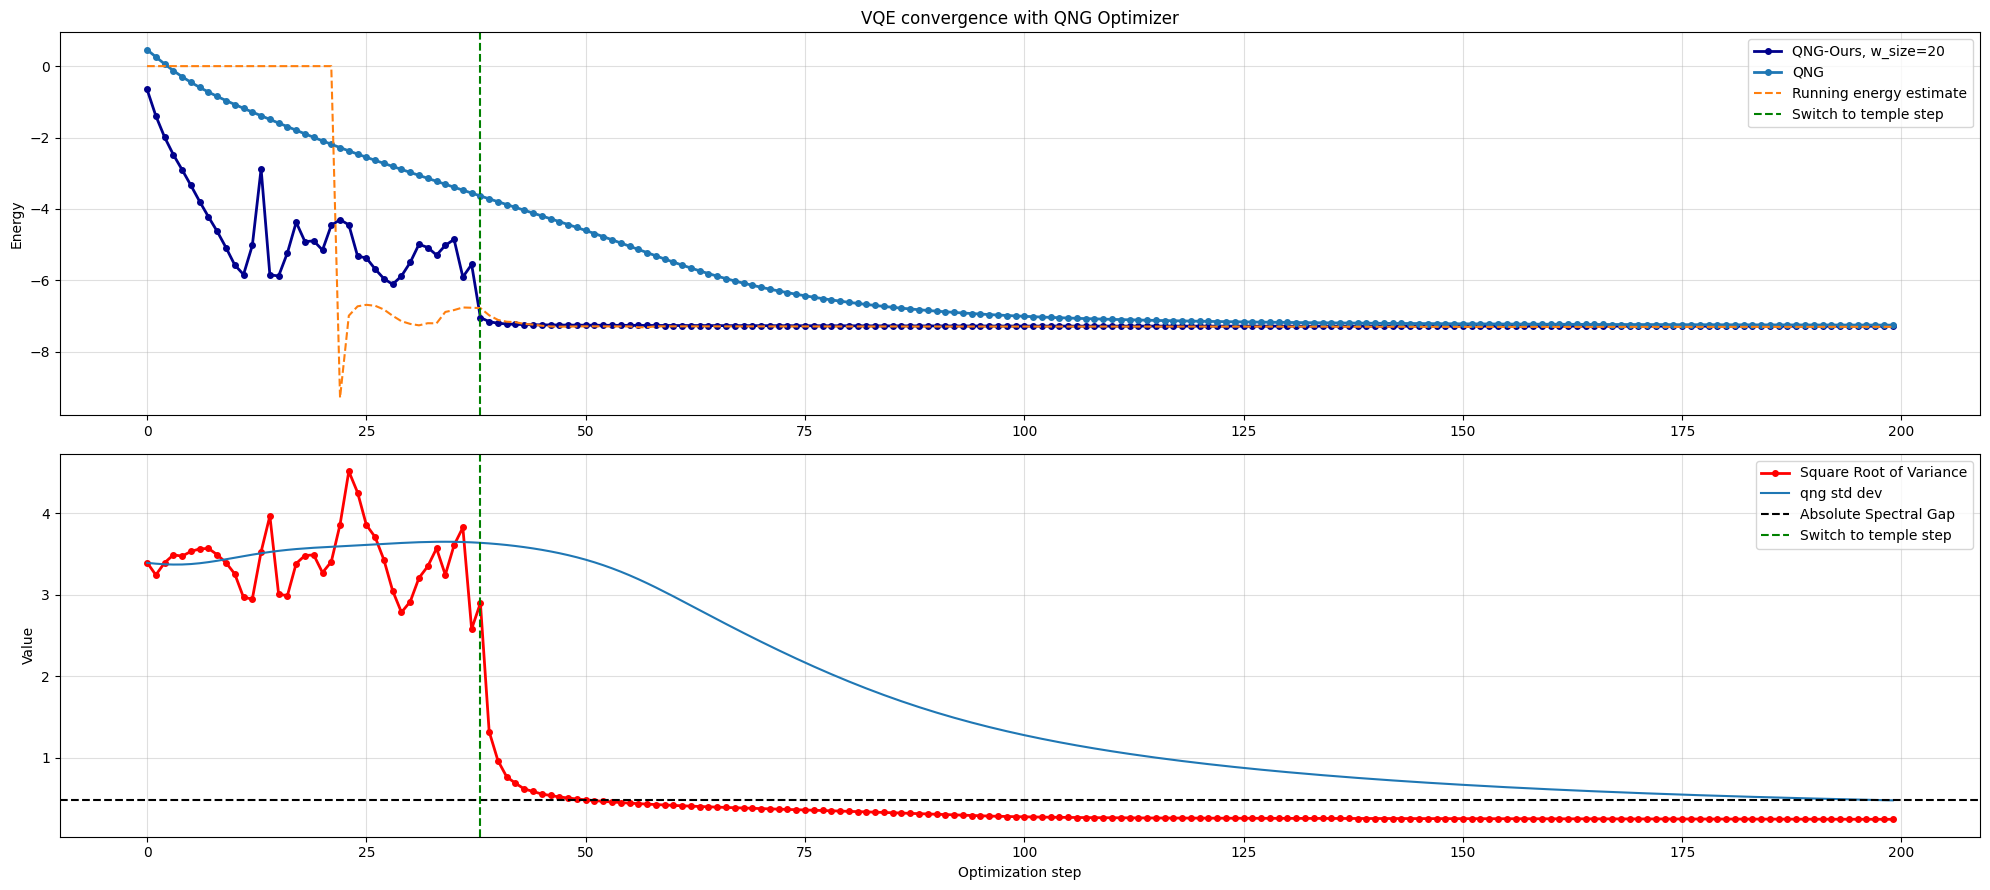

In [97]:
# Calculate the absolute spectral gap
absolute_spectral_gap = eigenvalues[1] - eigenvalues[0]

# Create the figure and subplots (2 rows, 1 column)
# Increased the overall figsize height to accommodate both plots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 9))

# --- Top Plot (axs[0]): Energy Convergence ---
axs[0].plot(energies_ours, 'o-', color='darkblue', lw=2, markersize=4, label=f"QNG-Ours, w_size={w_size}")
axs[0].plot(energies_adam, 'o-', lw=2, markersize=4, label="QNG")
axs[0].plot(running_energy_estimate, linestyle='--', label="Running energy estimate")
axs[0].set_ylabel("Energy")
axs[0].set_title("VQE convergence with QNG Optimizer")
axs[0].axvline(temple_step_when, color='green', linestyle='--', label="Switch to temple step")
axs[0].grid(alpha=0.4)
axs[0].legend()

# --- Bottom Plot (axs[1]): Variance and Spectral Gap ---
axs[1].plot(np.sqrt(vs_ours), 'o-', color='red', lw=2, markersize=4, label="Square Root of Variance")
axs[1].plot(np.sqrt(aaa), label="qng std dev")
axs[1].axhline(absolute_spectral_gap, color='black', linestyle='--', label="Absolute Spectral Gap")
axs[1].axvline(temple_step_when, color='green', linestyle='--', label="Switch to temple step")
axs[1].set_xlabel("Optimization step")
axs[1].set_ylabel("Value")
axs[1].grid(alpha=0.4)
axs[1].legend()

# Automatically adjust spacing to prevent text clipping/overlap
plt.tight_layout()

# Render the stacked plots
plt.show()

Linear Regression Results:
  Slope: 0.1846
  Intercept: -7.0112
  R-value (correlation coefficient): 0.7330
  R-squared (goodness of fit): 0.5372
  P-value: 0.0000
  Standard Error: 0.0163


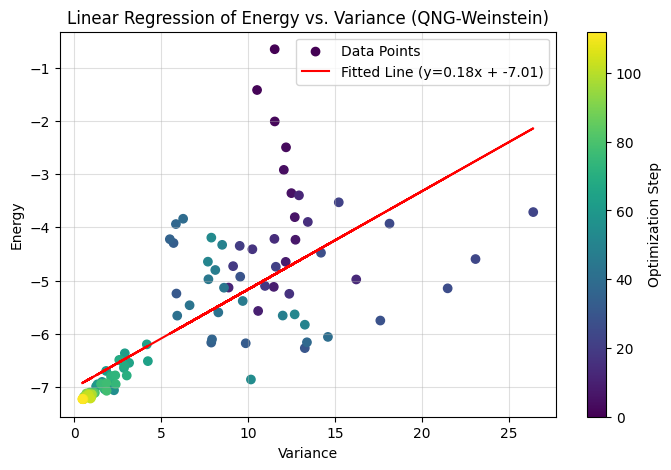

In [100]:
from scipy import stats

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(vs_ours, energies_ours)

# Calculate R-squared for goodness of fit
r_squared = r_value**2

print(f"Linear Regression Results:")
print(f"  Slope: {slope:.4f}")
print(f"  Intercept: {intercept:.4f}")
print(f"  R-value (correlation coefficient): {r_value:.4f}")
print(f"  R-squared (goodness of fit): {r_squared:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Standard Error: {std_err:.4f}")

# Plot the data and the fitted line
plt.figure(figsize=(8, 5))
plt.scatter(x=vs_ours, y=energies_ours, c=np.arange(len(vs_ours)), cmap='viridis', label='Data Points')
plt.plot(vs_ours, intercept + slope * np.array(vs_ours), color='red', label=f'Fitted Line (y={slope:.2f}x + {intercept:.2f})')
plt.xlabel("Variance")
plt.ylabel("Energy")
plt.title("Linear Regression of Energy vs. Variance (QNG-Weinstein)")
plt.colorbar(label="Optimization Step")
plt.grid(alpha=0.4)
plt.legend()
plt.show()